# IT2011 — Progress Review I: Individual Contribution
### Handling Missing Data
**IT Number:** IT25103807
**Dataset:** UCI Breast Cancer Wisconsin (Diagnostic) — 569 records, 30 features, 2 classes (Benign / Malignant)
**Group ID:** 2026-Y2-S1-IT2011


## Setup & Loading the Dataset

We load the dataset directly from `sklearn.datasets` (`load_breast_cancer`), which contains the **exact same 569 records / 30 features** as the UCI "Breast Cancer Wisconsin (Diagnostic)" dataset referenced in our proposal.

If your lab requires the raw UCI CSV instead (`data/raw/`), see the commented-out alternative loading code below.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# ---- Load dataset ----
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()
df.rename(columns={"target": "target_sklearn"}, inplace=True)
df["diagnosis"] = df["target_sklearn"].map({0: "M", 1: "B"})
df.drop(columns=["target_sklearn"], inplace=True)

feature_cols = [c for c in df.columns if c != "diagnosis"]

print("Shape:", df.shape)
df.head()

# ---- Alternative: load from the raw UCI CSV placed in data/raw/ ----
# df = pd.read_csv("data/raw/wdbc.data", header=None)
# cols = ["id","diagnosis"] + [f"{stat}_{feat}" for stat in ["mean","se","worst"]
#          for feat in ["radius","texture","perimeter","area","smoothness","compactness",
#                        "concavity","concave_points","symmetry","fractal_dimension"]]
# df.columns = cols
# df.drop(columns=["id"], inplace=True)


Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


## Handling Missing Data

**Technique:** Missing value detection & imputation.

**Explanation:** Before any modelling, every column must be checked for missing (`NaN`) values, because most ML algorithms cannot handle them directly — they will error out or silently bias the model.

**Justification for this dataset:** The UCI Breast Cancer Wisconsin (Diagnostic) dataset is documented as having **zero missing values across all 569 records** (confirmed in our proposal, Slide 4). We still demonstrate the full detection + imputation workflow below (using a temporary copy with artificially injected missing values) so the technique is properly shown and understood — then confirm the real dataset needs no imputation.


In [2]:
# ---- Step 1: check for missing values on the REAL data ----
missing_counts = df.isnull().sum()
print("Missing values per column (real data):")
print(missing_counts[missing_counts > 0] if missing_counts.sum() > 0 else "No missing values found in any column.")
print("\nTotal missing cells:", df.isnull().sum().sum())

Missing values per column (real data):
No missing values found in any column.

Total missing cells: 0


In [3]:
# ---- Step 2: demonstrate imputation on a synthetic copy (for viva demo purposes) ----
demo = df.drop(columns=["diagnosis"]).copy()
rng = np.random.default_rng(42)
mask = rng.random(demo.shape) < 0.03            # inject ~3% missing values
demo_missing = demo.mask(mask)

print("Injected missing values (demo only):", demo_missing.isnull().sum().sum())

imputer = SimpleImputer(strategy="mean")
demo_imputed = pd.DataFrame(imputer.fit_transform(demo_missing), columns=demo.columns)

print("Missing values after mean imputation:", demo_imputed.isnull().sum().sum())

Injected missing values (demo only): 494
Missing values after mean imputation: 0


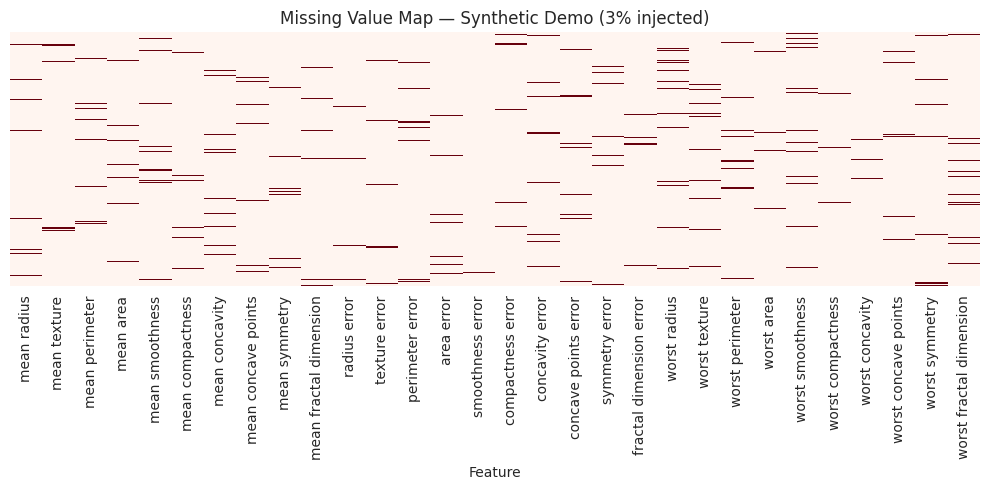

In [4]:
# ---- EDA Visualization: missingness heatmap (before imputation, demo data) ----
plt.figure(figsize=(10, 5))
sns.heatmap(demo_missing.isnull(), cbar=False, cmap="Reds", yticklabels=False)
plt.title("Missing Value Map — Synthetic Demo (3% injected)")
plt.xlabel("Feature")
plt.tight_layout()
plt.show()

**Interpretation:** The heatmap's scattered red marks show missingness spread randomly across features/rows in the synthetic demo — consistent with MCAR (missing completely at random) noise we injected. After `SimpleImputer(strategy="mean")`, all missing cells are filled and the count drops to 0. On the **real** dataset, `df.isnull().sum().sum()` returns 0, so no imputation step is required in the final pipeline — we simply carry this check forward as a safeguard.